<a href="https://colab.research.google.com/github/ID26S422/The-Feature-Matching-Project/blob/main/SIFT_Matchig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CV5570 Assignment 1

Assignment Focus: Image Stitching

---

Roll Number: ID26S422

Name: Vedhaanth N P J

---


In [5]:
#IMPORT FUNCTIONS

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.14.0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


image 1 size: (2268, 4032, 3)
image 1 dtype: uint8


image 2 size: (2268, 4032, 3)
image 2 dtype: uint8


image 3 size: (2268, 4032, 3)
image 3 dtype: uint8


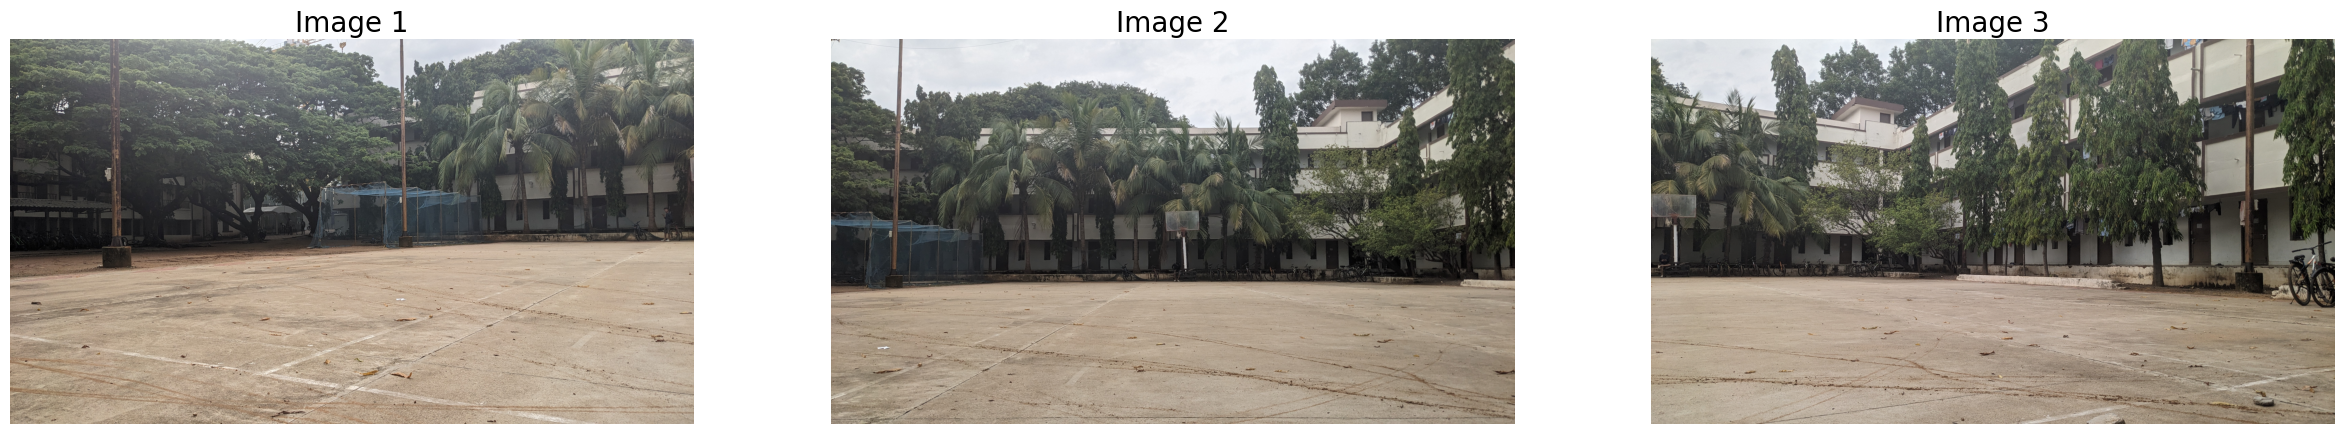

In [7]:
#Load Images

image1_path="/content/drive/MyDrive/Assignment 1 - CV5570/PXL_20260824_111109349.MP.jpg"
image2_path="/content/drive/MyDrive/Assignment 1 - CV5570/PXL_20260824_111123451.jpg"
image3_path="/content/drive/MyDrive/Assignment 1 - CV5570/PXL_20260824_111129452.jpg"

img1=np.array(Image.open(image1_path))
img2=np.array(Image.open(image2_path))
img3=np.array(Image.open(image3_path))

print("image 1 size:", img1.shape)
print("image 1 dtype:", img1.dtype)

print("\n")
print("image 2 size:", img2.shape)
print("image 2 dtype:", img2.dtype)

print("\n")
print("image 3 size:", img3.shape)
print("image 3 dtype:", img3.dtype)

plt.figure(figsize=(30,10))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.title("Image 1", fontsize=20)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img2)
plt.title("Image 2", fontsize=20)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img3)
plt.title("Image 3", fontsize=20)
plt.axis('off')

plt.show()

SIFT works on intensity and not colors. so we convert the rgb to gray first.

another note: plotting takes default cmap bgr, so mention gray.

image 1 in gray, shape: (2268, 4032)
image 2 in gray, shape: (2268, 4032)
image 3 in gray, shape: (2268, 4032)


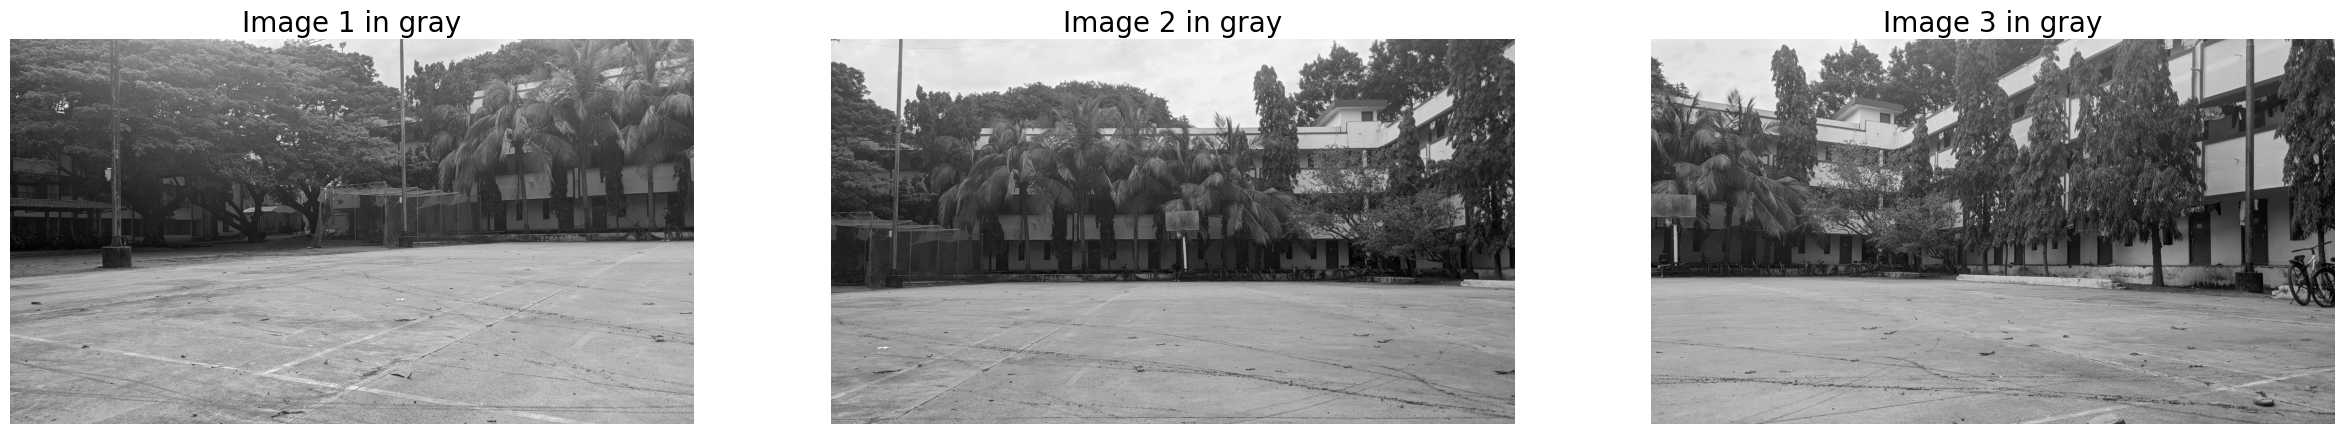

In [8]:
#RGBtoGRAY

img1_gray=cv2.cvtColor(img1,cv2.COLOR_RGB2GRAY)
img2_gray=cv2.cvtColor(img2,cv2.COLOR_RGB2GRAY)
img3_gray=cv2.cvtColor(img3,cv2.COLOR_RGB2GRAY)

print("image 1 in gray, shape:", img1_gray.shape)
print("image 2 in gray, shape:", img2_gray.shape)
print("image 3 in gray, shape:", img3_gray.shape)

plt.figure(figsize=(30,10))

plt.subplot(1,3,1)
plt.imshow(img1_gray, cmap='gray')
plt.title("Image 1 in gray", fontsize='20')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img2_gray, cmap='gray')
plt.title("Image 2 in gray", fontsize='20')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img3_gray, cmap='gray')
plt.title("Image 3 in gray", fontsize='20')
plt.axis('off')

plt.show()

# Working of SIFT:

---

*1.   Detection:*

Detect all points that look interesting in the intensity image, meaning points that can be reliably identified - like corners, edges.

**This outputs Keypoints**. These keypoints hold data of location, scale, orientation,intensity..

---

*2.   Description:*

This is to create a description of keypoint with information of ehat is around the keypoint in the given image to identify it in later stage for comparision.

**This outputs 128-dimension Descriptor**. These descriptors create local gradients and directions around the point acting like a fingerprint of the keypoint.

---

*3.   Matching:*

Now we have keypoints and descriptor respective to multiple images. when tried to compare and match, some of the descriptors(and keypoint) in one image match with the respective next image.

Where there is a match, they are called **corresponding points**. these points will be used when the images will be stiched.

---

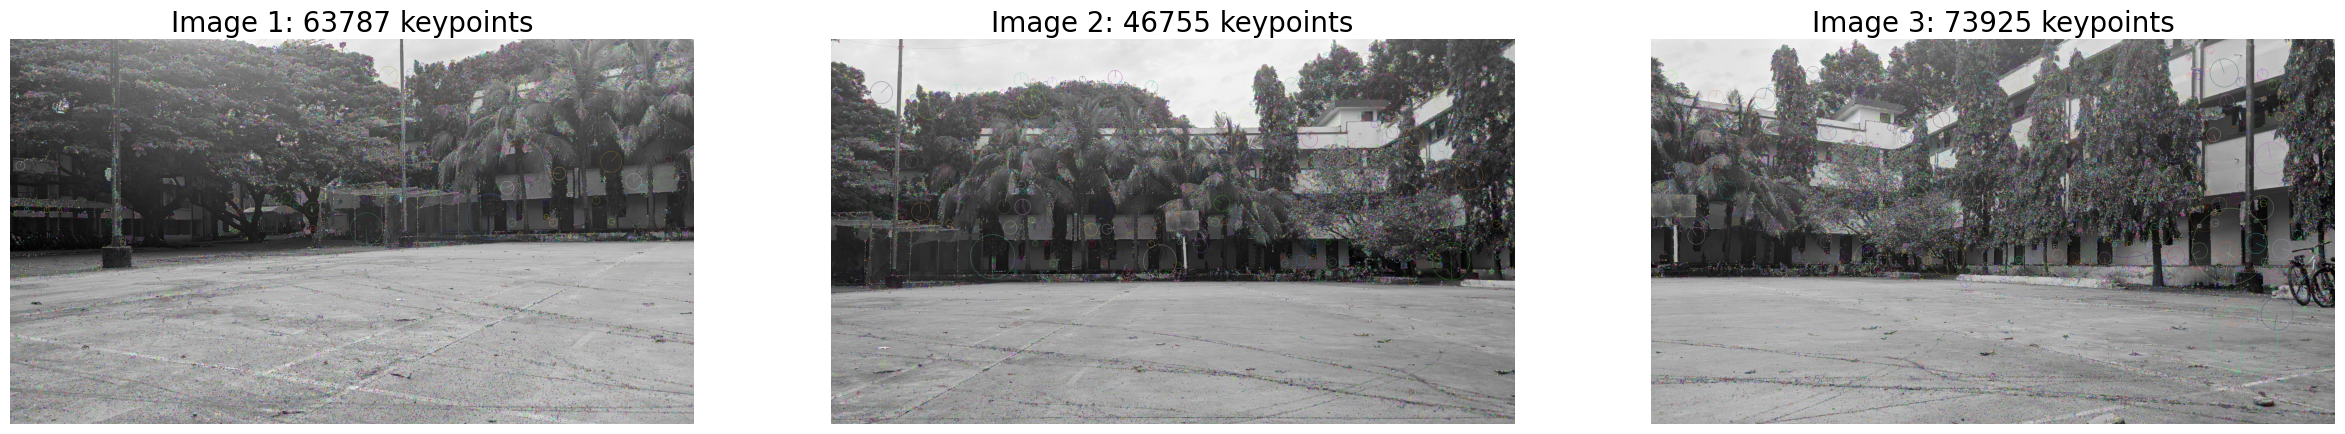

In [9]:
#sift object creation
sift = cv2.SIFT_create()

#finding keypoints
keypoints1 = sift.detect(img1_gray, None)
keypoints2 = sift.detect(img2_gray, None)
keypoints3 = sift.detect(img3_gray, None)

#         Question - what is this for???
#####################################
img1_keypoints = cv2.drawKeypoints(
    img1_gray,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img2_keypoints = cv2.drawKeypoints(
    img2_gray,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img3_keypoints = cv2.drawKeypoints(
    img3_gray,
    keypoints3,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

#plotting keypoints
plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
plt.imshow(img1_keypoints, cmap="gray")
plt.title(f"Image 1: {len(keypoints1)} keypoints", fontsize='20')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img2_keypoints, cmap="gray")
plt.title(f"Image 2: {len(keypoints2)} keypoints", fontsize='20')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img3_keypoints, cmap="gray")
plt.title(f"Image 3: {len(keypoints3)} keypoints", fontsize='20')
plt.axis("off")

plt.show()

circles - feauture size/scale -**size** - At a particular location, SIFT checks how the local image structure behaves across scales; if it produces a local extremum at one scale, that scale becomes the characteristic scale (size) of the keypoint

dots - feature location - **position**

how strongly the SIFT detector respond to the feature - how strong is the feature? - **response**

radius line - orientation of the feature - useful for rotation invarance. - **angle** - Many gradient contributions accumulate in orientation bins, and the bin with the strongest accumulated magnitude determines the dominant orientation.


**octave** - keypoint info encoded

all the above and some more details togather form a keypoint

the mechanism: take different blurred versions of images by varying sigma. subtract the different blurred images. in each dog image there will be some highlighted points which are local extrema of that scale(scale of sigma-the circle)

feature detection - keypoints, is done now.

Image

  ↓

Different σ → blurred images

  ↓

Difference of Gaussians

  ↓

Search in space + scale

  ↓
  
Local extrema

  ↓

Keypoint location + characteristic scale

  ↓

Refinement / response

  ↓

Orientation assignment

  ↓

Final keypoint

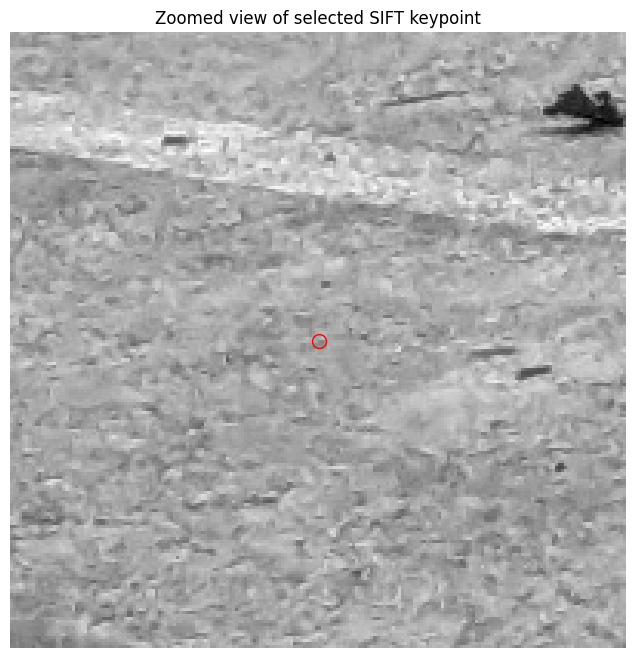

Position (x, y): (932.9752197265625, 1945.9853515625)
Size: 1.9593286514282227
Angle: 278.34002685546875
Response: 0.01778070256114006
Octave: 6291967


In [10]:
#keypoint visualization

kp = keypoints1[12369]

x, y = kp.pt
x, y = int(x), int(y)

# Size of the zoomed region around the keypoint
zoom_size = 100

# Crop around the keypoint
crop = img1_gray[
    max(0, y - zoom_size): y + zoom_size,
    max(0, x - zoom_size): x + zoom_size
]

# Show the crop enlarged
plt.figure(figsize=(8, 8))
plt.imshow(crop, cmap="gray")
plt.scatter(
    x - max(0, x - zoom_size),
    y - max(0, y - zoom_size),
    s=100,
    facecolors="none",
    edgecolors="red"
)
plt.title("Zoomed view of selected SIFT keypoint")
plt.axis("off")
plt.show()

# Print its properties
print("Position (x, y):", kp.pt)
print("Size:", kp.size)
print("Angle:", kp.angle)
print("Response:", kp.response)
print("Octave:", kp.octave)

TBD

Response represents the strength of the SIFT detector's response to a local feature—how strongly that location satisfies SIFT's criterion for being a distinctive keypoint. Size represents the characteristic spatial scale at which SIFT detects that keypoint, i.e., the size of the local image structure being identified, not necessarily the physical size of the object.

lets do descriptors now!

In [11]:
#Find Descriptors of Keypoints

keypoints1, descriptors1 = sift.compute(img1_gray, keypoints1)
keypoints2, descriptors2 = sift.compute(img2_gray, keypoints2)
keypoints3, descriptors3 = sift.compute(img3_gray, keypoints3)

print("Image 1")
print("Number of keypoints:", len(keypoints1))
print("Descriptor shape:", descriptors1.shape)

print("\nImage 2")
print("Number of keypoints:", len(keypoints2))
print("Descriptor shape:", descriptors2.shape)

print("\nImage 3")
print("Number of keypoints:", len(keypoints3))
print("Descriptor shape:", descriptors3.shape)

Image 1
Number of keypoints: 63787
Descriptor shape: (63787, 128)

Image 2
Number of keypoints: 46755
Descriptor shape: (46755, 128)

Image 3
Number of keypoints: 73925
Descriptor shape: (73925, 128)


[  0.   0.   1.  18.  17.  17.  97.  12.   4.   0.   0.   4.  12.  15.
 146. 102.   1.   0.   0.   0.   0.   3.  83.  74.   0.   0.   0.   0.
   0.   0.   0.   0.  19.  13.  17.  21.  26.  16.  92.  22. 146.  41.
  17.   4.   2.   8. 146. 141.  19.   7.  25.   6.   0.  24. 146.  47.
   0.   0.   1.   0.   0.   0.   7.   0.  33.   7.   9.  36.  42.   6.
  14.  25. 146. 140.  72.   6.   4.   3.  20.  57.  23.  47. 146.  41.
   1.   7.  34.  10.   0.   0.  16.   4.   0.   0.   1.   0.   5.   3.
   3.   1.   1.   3.  57.  78.  25.  16.  11.   1.   0.  10.  39.  78.
   1.   5.  38.  11.   3.  44.  36.   5.   0.   0.   3.   1.   0.   5.
   6.   0.]

Descriptor for Keypoint 0:
[[  0.   0.   1.  18.  17.  17.  97.  12.]
 [  4.   0.   0.   4.  12.  15. 146. 102.]
 [  1.   0.   0.   0.   0.   3.  83.  74.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [ 19.  13.  17.  21.  26.  16.  92.  22.]
 [146.  41.  17.   4.   2.   8. 146. 141.]
 [ 19.   7.  25.   6.   0.  24. 146.  47.]
 [  0.   0.   1.   0

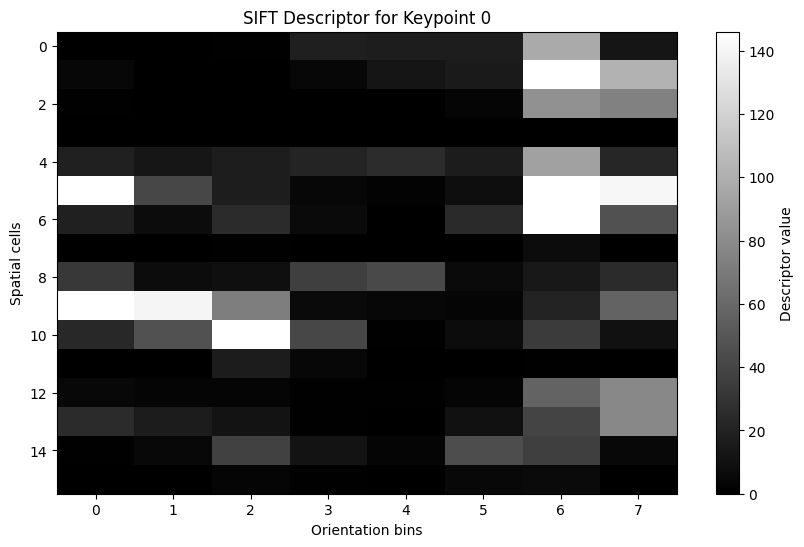

In [12]:
#descriptor example: a one line array
print(descriptors1[0])

#descriptor array visualizing the 8 bins of each 16 cells
print("\nDescriptor for Keypoint 0:")
print(descriptors1[0].reshape(16, 8))
print("\n")

#descriptor visualize in a graph:
plt.figure(figsize=(10, 6))

plt.imshow(
    descriptors1[0].reshape(16, 8),
    cmap="gray",
    aspect="auto"
)

plt.colorbar(label="Descriptor value")
plt.xlabel("Orientation bins")
plt.ylabel("Spatial cells")
plt.title("SIFT Descriptor for Keypoint 0")

plt.show()

A keypoint is a single pixel. which is derived after sifting.

once done, a neighborhood of keypoit is take. the scale of it is decided by size of keypoint. each pixel iside has gradiets. the neighborhood is divided into 16 cells (4*4). ad each cell's 8 gradiets magitudes are calculated based on pixel gradients in each cell.

overall each keypoint has 16 cells of 8 bins each leadig to 128 values. this allows to find the similar keypoint with similar neighborhood for matching - next step.


In [15]:
#BF matchig object creation
bf = cv2.BFMatcher()

#do BF(brute force) matchig and list 2 best matches:
matches12 = bf.knnMatch(descriptors1, descriptors2, k=2)

print("shape of matches12", len(matches12))  #should be equal to no of keypoints
print(matches12[0])                          #should give best and second best (2matches since k=2)

shape of matches12 63787
(< cv2.DMatch 0x7ebb57ae8f10>, < cv2.DMatch 0x7ebb6c3f2b90>)


In [25]:
#lets look at the best matches of a descriptor
m1 = matches12[0][0]
m2 = matches12[0][1]

print("Best match distance:", m1.distance)
print("\nSecond-best distance:", m2.distance)

Best match distance: 317.25225830078125

Second-best distance: 332.91741943359375


Now we have compared each descriptor of image 1 to image 2 ad found matches.

we found 2 best matches.

but if the best and second best are very close values, the we cannot consider it as a distinct match. so we take lowes ratio as below.

In [24]:
#find valid matches using a basic lowes ratio formula. keeping ratio at 0.75.
good_matches12 = []

for m1,m2 in matches12:
  if m1.distance/m2.distance<0.75:
    good_matches12.append(m1)


print(len(good_matches12)) #gives how many matches are actually valid.

2340


we have to repeat the same for the images 2,3

In [26]:
matches23 = bf.knnMatch(descriptors2, descriptors3, k=2)

print("shape of matches12", len(matches23))
print(matches23[0])

m3 = matches23[0][0]
m4 = matches23[0][1]

print("\nBest match distance:", m3.distance)
print("\nSecond-best distance:", m4.distance)

good_matches23 = []

for m3,m4 in matches23:
  if m3.distance/m4.distance<0.75:
    good_matches23.append(m3)


print("\n",len(good_matches23))

shape of matches12 46755
(< cv2.DMatch 0x7ebb3aa6c830>, < cv2.DMatch 0x7ebb3aa6f870>)

Best match distance: 254.86074829101562

Second-best distance: 257.1633605957031

 3278


let us now visualize matches as asked for. we re takig only some poits, coz there are many matched poits and will look messy. also those that are taken are best matches sorted by distace(distace in BF method)

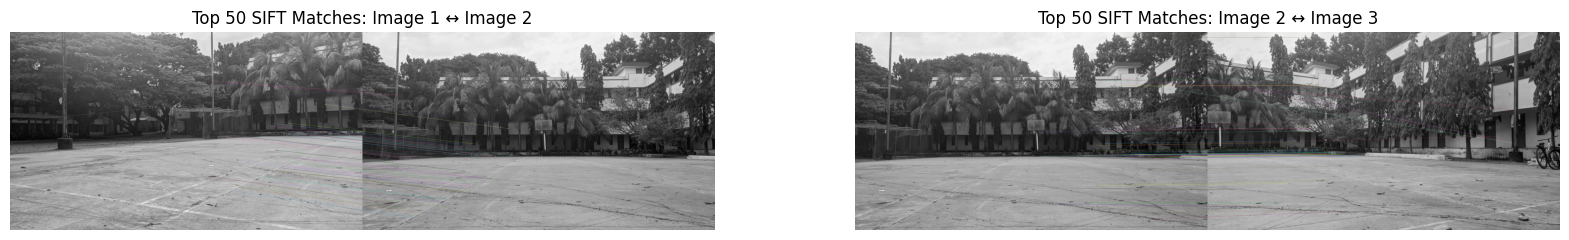

In [27]:
#sorting by distance the matches between image 1,2
good_matches12 = sorted(
    good_matches12,
    key=lambda m: m.distance
)

#sorting by distance the matches between image 2,3
good_matches23 = sorted(
    good_matches23,
    key=lambda m: m.distance
)

#plotting the 50 first matches of the sorted list for images 1,2 and 2,3:
num_matches = 50

img_matches12 = cv2.drawMatches(
    img1_gray,
    keypoints1,
    img2_gray,
    keypoints2,
    good_matches12[:num_matches],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

img_matches23 = cv2.drawMatches(
    img2_gray,
    keypoints2,
    img3_gray,
    keypoints3,
    good_matches23[:num_matches],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.imshow(img_matches12, cmap="gray")
plt.title("Top 50 SIFT Matches: Image 1 ↔ Image 2")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_matches23, cmap="gray")
plt.title("Top 50 SIFT Matches: Image 2 ↔ Image 3")
plt.axis("off")

plt.show()

we can see some matches match but some are not - they are irrelevant. nevertheless, it works, not 100 percent.